# The monsoon record, 1871 to 2026

Before I can ask what a bad monsoon does to growth or food prices, I need one clean list of how much it actually rained each year. So this notebook builds that list. It takes the June to September (JJAS) all-India rainfall from two official sources, puts them on the same footing, and saves one file that the other notebooks use.

The two sources are:

1. IITM Pune's homogeneous all-India rainfall series, which covers 1871 to 2016 and is the series most long-run studies of the monsoon use.
2. IMD's own end-of-season figures for 2017 to 2026, which I typed in by hand from IMD reports and press releases, with the link for each year in the file.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

RAW = "data/raw/"
CLEAN = "data/clean/"

## IITM series, 1871 to 2016

The file is a fixed-width text file with six blocks, one for all-India and five for regions. I only need the all-India block for now. The values are in tenths of a millimetre, so I divide by 10.

In [2]:
with open(RAW + "iitm_region_rainfall_1871_2016.txt") as f:
    lines = f.read().split("\n")

# the all-India block is the first one in the file, its column header line starts with YEAR
header_row = next(i for i, line in enumerate(lines) if line.startswith("YEAR"))
columns = lines[header_row].split()

rows = []
for line in lines[header_row + 2:]:
    if line.startswith("-"):  # dashed line marks the end of the yearly rows
        break
    rows.append(line.split())

iitm = pd.DataFrame(rows, columns=columns).astype(int).set_index("YEAR") / 10
iitm.index.name = "year"
print(iitm.shape, iitm.index.min(), "to", iitm.index.max())
iitm.head()

(146, 17) 1871 to 2016


,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,JF,MAM,JJAS,OND,ANN
year,,,,,,,,,,,,,,,,,
1871,19.6,10.7,14.5,33.9,63.6,208.0,277.8,179.4,183.6,36.8,32.4,6.7,30.3,112.0,848.7,75.8,1067.0
1872,7.6,7.5,7.3,24.0,43.8,189.2,291.3,245.2,187.9,78.5,27.6,19.1,15.1,75.1,913.6,125.2,1128.9
1873,3.7,13.5,15.0,24.3,42.8,113.0,264.5,214.2,165.6,60.7,11.5,9.0,17.2,82.1,757.3,81.2,937.8
1874,8.6,15.8,10.7,16.9,68.3,227.9,306.9,233.5,206.2,93.2,18.7,4.0,24.4,95.9,974.5,115.9,1210.6
1875,9.9,11.4,13.1,23.2,50.6,192.6,307.9,218.7,210.5,56.6,6.3,7.1,21.3,86.9,929.7,70.0,1107.8


A quick check that I read it right. The JJAS column should equal June + July + August + September, give or take rounding.

In [3]:
gap = (iitm[["JUN", "JUL", "AUG", "SEP"]].sum(axis=1) - iitm["JJAS"]).abs().max()
print("largest gap between JJAS and the sum of the four months:", round(gap, 1), "mm")

largest gap between JJAS and the sum of the four months: 0.1 mm


## IMD figures, 2017 to 2026

IMD reports each year as a percentage of its long period average (LPA), but the LPA itself changed twice in these ten years (887.5 mm, then 880.6 mm, then 868.6 mm). So the percentages IMD printed are not comparable across years. I ignore them for the joined series and use the rainfall in mm instead, compared against one fixed average, the current LPA of 868.6 mm (1971 to 2020).

In [4]:
imd = pd.read_csv(RAW + "imd_monsoon_2017_2026.csv").set_index("year")
IMD_LPA = 868.6
imd["pct_of_normal"] = imd["jjas_mm"] / IMD_LPA * 100
imd[["jjas_mm", "jjas_pct_lpa", "pct_of_normal"]].round(1)

,jjas_mm,jjas_pct_lpa,pct_of_normal
year,,,
2017,845.9,95.0,97.4
2018,804.0,91.0,92.6
2019,968.3,110.0,111.5
2020,957.6,109.0,110.2
2021,874.6,99.0,100.7
2022,925.0,106.0,106.5
2023,820.0,94.4,94.4
2024,934.8,108.0,107.6
2025,936.8,108.0,107.9


## Putting the two together

The two series come from different rain gauge networks. IITM uses a fixed set of 306 stations, and IMD now uses a few thousand. Because of that, IITM's average JJAS rainfall over 1971 to 2016 is about 832 mm while IMD's LPA is 868.6 mm, so I can't just stack the mm values on top of each other. There's also no year that's in both files, so I can't line them up on an overlap either.

What I do instead is measure every year against its own source's normal. IITM years are a percentage of IITM's 1971 to 2016 average, and IMD years are a percentage of IMD's 1971 to 2020 LPA. The two base periods are almost the same, so "90% of normal" means roughly the same thing on both sides of the join.

In [5]:
iitm_normal = iitm.loc[1971:2016, "JJAS"].mean()
print("IITM 1971-2016 average JJAS rainfall:", round(iitm_normal, 1), "mm")

old = pd.DataFrame({
    "jjas_mm": iitm["JJAS"],
    "pct_of_normal": iitm["JJAS"] / iitm_normal * 100,
    "source": "IITM",
})
new = imd[["jjas_mm", "pct_of_normal"]].assign(source="IMD")

monsoon = pd.concat([old, new])
monsoon["departure"] = monsoon["pct_of_normal"] - 100

IITM 1971-2016 average JJAS rainfall: 832.3 mm


To see if this method gives sensible numbers, I compare a few drought years with the percentages IMD itself reported for them. They won't match exactly because of the different networks, but they should tell the same story.

In [6]:
imd_reported = {2002: 81, 2009: 78, 2014: 88, 2015: 86}  # IMD end-of-season figures, % of LPA
check = pd.DataFrame({
    "this series": monsoon.loc[list(imd_reported), "pct_of_normal"].round(1),
    "IMD reported": pd.Series(imd_reported),
})
check

,this series,IMD reported
2002,77.7,81
2009,84.3,78
2014,88.5,88
2015,87.5,86


## Labelling the years

I use IMD's categories for the season as a whole: deficient below 90% of normal, below normal 90 to 95, normal 96 to 104, above normal 105 to 110 and excess above 110. IMD applies these to the rounded percentage, so I do the same.

In [7]:
def category(pct):
    pct = round(pct)
    if pct < 90:
        return "deficient"
    if pct <= 95:
        return "below normal"
    if pct <= 104:
        return "normal"
    if pct <= 110:
        return "above normal"
    return "excess"

monsoon["category"] = monsoon["pct_of_normal"].apply(category)
monsoon["category"].value_counts()

category
normal          46
above normal    40
excess          29
deficient       22
below normal    19
Name: count, dtype: int64

In [8]:
deficient = monsoon[monsoon["category"] == "deficient"].sort_values("pct_of_normal")
print(len(deficient), "deficient years since 1871")
deficient[["jjas_mm", "pct_of_normal", "source"]].round(1)

22 deficient years since 1871


,jjas_mm,pct_of_normal,source
year,,,
1877,604.0,72.6,IITM
1899,629.0,75.6,IITM
2002,646.8,77.7,IITM
1918,650.8,78.2,IITM
1972,652.8,78.4,IITM
1987,697.1,83.8,IITM
2009,702.0,84.3,IITM
1979,707.7,85.0,IITM
1965,709.3,85.2,IITM


Each bar is one year's departure from normal. Red bars are years below normal and blue bars are years above it. The dashed line is the 90% mark, below which IMD calls a year deficient.

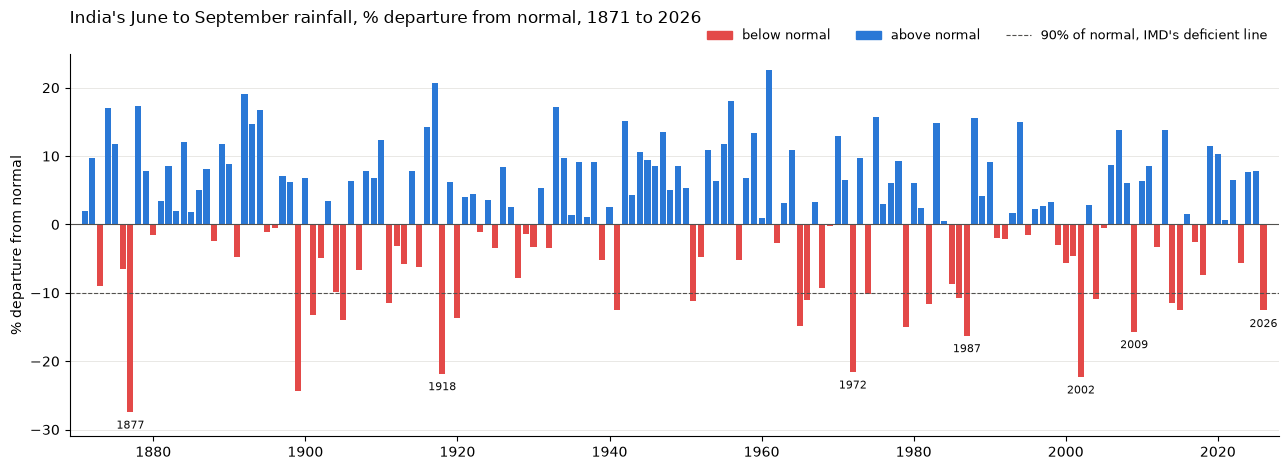

In [9]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

colors = ["#e34948" if d < 0 else "#2a78d6" for d in monsoon["departure"]]

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.bar(monsoon.index, monsoon["departure"], color=colors, width=0.8)
ax.axhline(0, color="#52514e", linewidth=0.8)
ax.axhline(-10, color="#52514e", linewidth=0.8, linestyle="--")

for year in [1877, 1918, 1972, 1987, 2002, 2009, 2026]:
    d = monsoon.loc[year, "departure"]
    ax.annotate(str(year), (year, d), xytext=(0, -12), textcoords="offset points",
                ha="center", fontsize=8, color="#0b0b0b")

legend_items = [
    Patch(color="#e34948", label="below normal"),
    Patch(color="#2a78d6", label="above normal"),
    Line2D([0], [0], color="#52514e", linewidth=0.8, linestyle="--", label="90% of normal, IMD's deficient line"),
]
ax.legend(handles=legend_items, loc="lower right", bbox_to_anchor=(1, 1.0), ncol=3, frameon=False, fontsize=9)

ax.set_title("India's June to September rainfall, % departure from normal, 1871 to 2026", loc="left", pad=22)
ax.set_ylabel("% departure from normal")
ax.set_ylim(-31, 25)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e5e4e0", linewidth=0.6)
ax.set_axisbelow(True)
ax.set_xlim(1869, 2028)
plt.tight_layout()
plt.show()

## Saving the joined series

This is the file the other notebooks read.

In [10]:
monsoon.round(2).to_csv(CLEAN + "monsoon_rainfall_1871_2026.csv")
monsoon.tail(12).round(1)

,jjas_mm,pct_of_normal,source,departure,category
year,,,,,
2015,728.1,87.5,IITM,-12.5,deficient
2016,844.9,101.5,IITM,1.5,normal
2017,845.9,97.4,IMD,-2.6,normal
2018,804.0,92.6,IMD,-7.4,below normal
2019,968.3,111.5,IMD,11.5,excess
2020,957.6,110.2,IMD,10.2,above normal
2021,874.6,100.7,IMD,0.7,normal
2022,925.0,106.5,IMD,6.5,above normal
2023,820.0,94.4,IMD,-5.6,below normal
